In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/ecommerce-analytics'

# Use customers-only data for RFM (needs Customer ID)
df = pd.read_csv(f'{BASE}/data/processed/stage2_customers.csv',
                 parse_dates=['InvoiceDate'])

# Keep only positive revenue rows
df = df[df['TotalRevenue'] > 0]

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

print(f"Loaded: {len(df):,} rows")
print(f"Unique customers: {df['Customer ID'].nunique():,}")

Mounted at /content/drive
Loaded: 779,425 rows
Unique customers: 5,878


In [ ]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    recency   = ('InvoiceDate',
                 lambda x: (reference_date - x.max()).days),
    frequency = ('Invoice',    'nunique'),
    monetary  = ('TotalRevenue', 'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)

print("RFM table — first 5 rows:")
print(rfm.head().to_string(index=False))
print(f"\nTotal customers scored: {len(rfm):,}")
print(f"\nRecency   — min: {rfm['recency'].min()} days  "
      f"max: {rfm['recency'].max()} days")
print(f"Frequency — min: {rfm['frequency'].min()}  "
      f"max: {rfm['frequency'].max()} orders")
print(f"Monetary  — min: £{rfm['monetary'].min():.0f}  "
      f"max: £{rfm['monetary'].max():,.0f}")

RFM table — first 5 rows:
 Customer ID  recency  frequency  monetary
     12346.0      326         12  77556.46
     12347.0        2          8   4921.53
     12348.0       75          5   2019.40
     12349.0       19          4   4428.69
     12350.0      310          1    334.40

Total customers scored: 5,878

Recency   — min: 1 days  max: 739 days
Frequency — min: 1  max: 398 orders
Monetary  — min: £3  max: £580,987


In [ ]:
rfm['R_score'] = pd.qcut(rfm['recency'],
                            q=4,
                            labels=[4, 3, 2, 1])

rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=4,
                          labels=[1, 2, 3, 4])

rfm['M_score'] = pd.qcut(rfm['monetary'],
                          q=4,
                          labels=[1, 2, 3, 4])

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

rfm['RFM_score'] = (rfm['R_score'].astype(str) +
                    rfm['F_score'].astype(str) +
                    rfm['M_score'].astype(str))

rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("Scores added:")
print(rfm[['Customer ID','recency','frequency','monetary',
           'R_score','F_score','M_score',
           'RFM_score','RFM_total']].head(8).to_string(index=False))

Scores added:
 Customer ID  recency  frequency  monetary  R_score  F_score  M_score RFM_score  RFM_total
     12346.0      326         12  77556.46        2        4        4       244         10
     12347.0        2          8   4921.53        4        4        4       444         12
     12348.0       75          5   2019.40        3        3        3       333          9
     12349.0       19          4   4428.69        4        3        4       434         11
     12350.0      310          1    334.40        2        1        1       211          4
     12351.0      375          1    300.93        2        1        1       211          4
     12352.0       36         10   2849.84        3        4        4       344         11
     12353.0      204          2    406.76        2        2        2       222          6


In [ ]:
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    if r >= 4 and f >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal customer'
    elif r >= 4 and f <= 2:
        return 'New customer'
    elif r >= 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3:
        return 'At risk'
    elif r == 1 and f >= 3:
        return 'Lost champion'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

segment_summary = (rfm.groupby('Segment')
                   .agg(
                       num_customers = ('Customer ID', 'count'),
                       avg_recency   = ('recency',   'mean'),
                       avg_frequency = ('frequency', 'mean'),
                       avg_monetary  = ('monetary',  'mean'),
                       total_revenue = ('monetary',  'sum')
                   )
                   .round(1)
                   .sort_values('total_revenue', ascending=False)
                   .reset_index())

segment_summary['revenue_%'] = (
    segment_summary['total_revenue'] /
    segment_summary['total_revenue'].sum() * 100
).round(1)

print("=== SEGMENT SUMMARY ===")
print(segment_summary.to_string(index=False))

=== SEGMENT SUMMARY ===
       Segment  num_customers  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_%
      Champion            774         10.7           22.2       12394.3      9593153.7       55.2
Loyal customer           1285         41.4            7.3        2907.7      3736380.9       21.5
       At risk            880        277.1            6.5        2460.3      2165027.5       12.5
          Lost           2045        411.6            1.5         546.1      1116794.6        6.4
     Promising            558         57.0            1.7         685.4       382457.2        2.2
  New customer            336         13.7            1.9        1133.9       380990.3        2.2


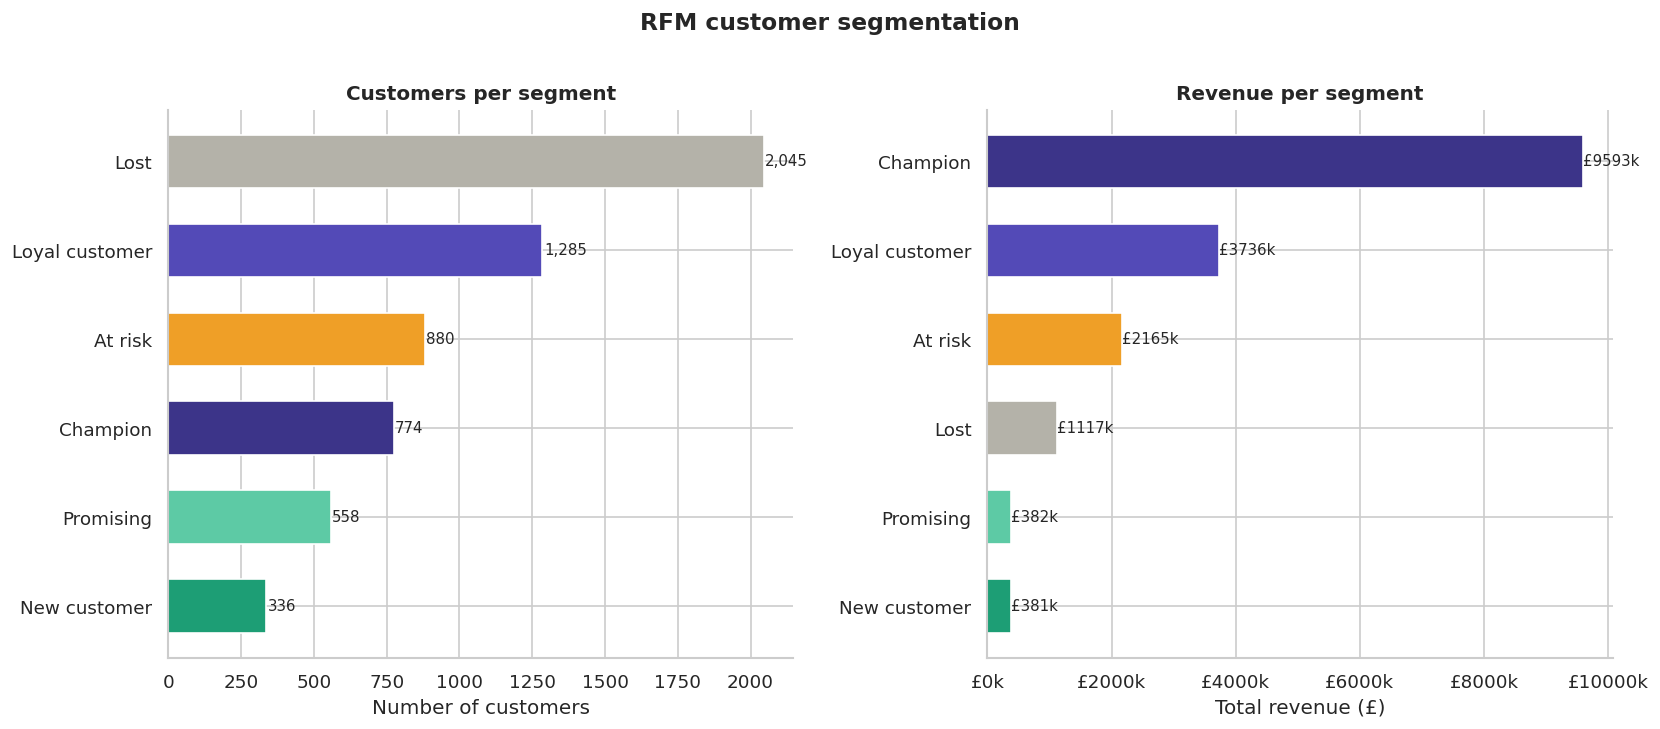

Chart 7 saved.


In [ ]:
seg_colors = {
    'Champion'      : '#3C3489',
    'Loyal customer': '#534AB7',
    'New customer'  : '#1D9E75',
    'Promising'     : '#5DCAA5',
    'At risk'       : '#EF9F27',
    'Lost champion' : '#D85A30',
    'Lost'          : '#B4B2A9',
}

seg_order = segment_summary.sort_values(
    'num_customers', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: customers per segment
colors_left = [seg_colors.get(s, '#888780')
               for s in seg_order['Segment']]
bars = ax1.barh(seg_order['Segment'],
                seg_order['num_customers'],
                color=colors_left, height=0.6)
for bar, val in zip(bars, seg_order['num_customers']):
    ax1.text(bar.get_width() + 5,
             bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_title('Customers per segment',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of customers')

# Right: revenue per segment
seg_rev = segment_summary.sort_values(
    'total_revenue', ascending=True)
colors_right = [seg_colors.get(s, '#888780')
                for s in seg_rev['Segment']]
bars2 = ax2.barh(seg_rev['Segment'],
                 seg_rev['total_revenue'],
                 color=colors_right, height=0.6)
for bar, val in zip(bars2, seg_rev['total_revenue']):
    ax2.text(bar.get_width() + 100,
             bar.get_y() + bar.get_height()/2,
             f'£{val/1000:.0f}k', va='center', fontsize=9)
ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))
ax2.set_title('Revenue per segment',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Total revenue (£)')

plt.suptitle('RFM customer segmentation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart7_rfm_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved.")

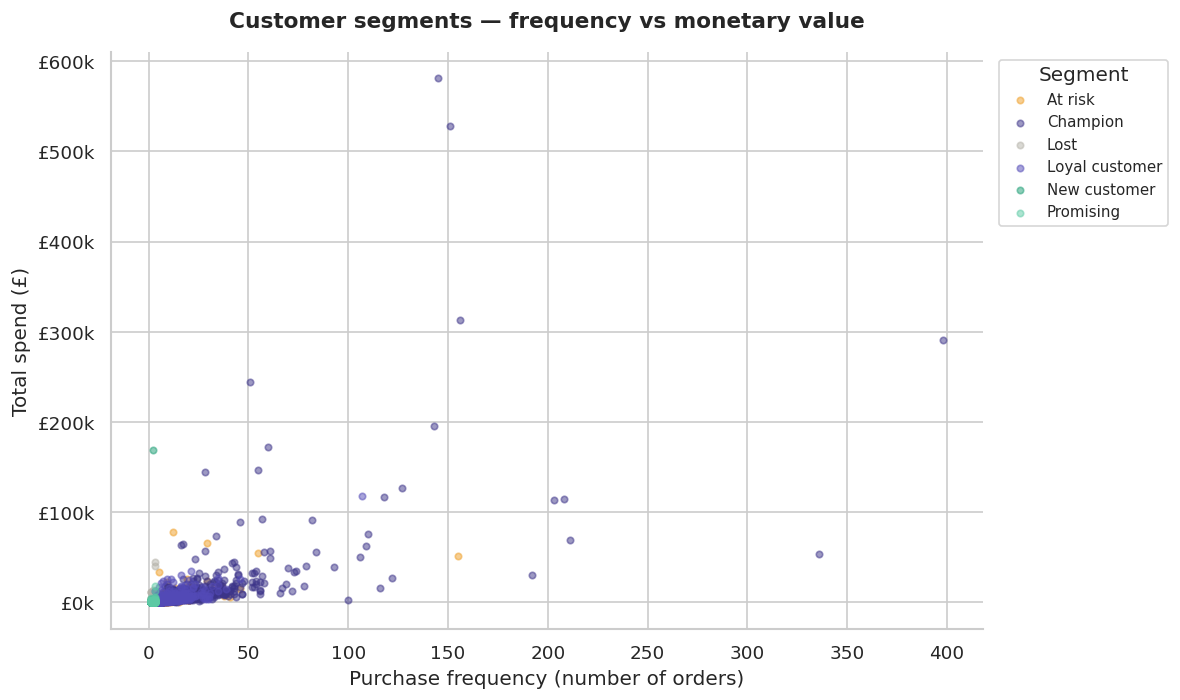

Chart 8 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for segment, group in rfm.groupby('Segment'):
    ax.scatter(group['frequency'],
               group['monetary'],
               label=segment,
               color=seg_colors.get(segment, '#888780'),
               alpha=0.5, s=15)

ax.set_xlabel('Purchase frequency (number of orders)')
ax.set_ylabel('Total spend (£)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))
ax.set_title('Customer segments — frequency vs monetary value',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/chart8_rfm_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved.")

In [ ]:
actions = {
    'Champion'      : 'Reward them. Ask for reviews. Offer early access.',
    'Loyal customer': 'Upsell higher value products. Send loyalty rewards.',
    'New customer'  : 'Onboarding campaign. Guide second purchase.',
    'Promising'     : 'Build relationship. Offer membership benefits.',
    'At risk'       : 'Send win-back campaign. Offer discount now.',
    'Lost champion' : 'Aggressive re-engagement. Personalised offer.',
    'Lost'          : 'Low priority. Generic reactivation email only.',
}

rfm['Recommended_action'] = rfm['Segment'].map(actions)

final_summary = (rfm.groupby(['Segment','Recommended_action'])
                 .agg(
                     customers     = ('Customer ID', 'count'),
                     total_revenue = ('monetary', 'sum'),
                     avg_spend     = ('monetary', 'mean')
                 )
                 .round(0)
                 .reset_index()
                 .sort_values('total_revenue', ascending=False))

print("=== BUSINESS ACTION PLAN ===")
print(final_summary[['Segment','customers',
                      'total_revenue',
                      'Recommended_action'
                      ]].to_string(index=False))

# Save full RFM table to Drive
rfm.to_csv(f'{BASE}/data/processed/stage5_rfm.csv',
           index=False)
final_summary.to_csv(
    f'{BASE}/data/processed/stage5_segment_summary.csv',
    index=False)

print("\nStage 5 DONE!")
print("Files saved:")
print("  stage5_rfm.csv")
print("  stage5_segment_summary.csv")

=== BUSINESS ACTION PLAN ===
       Segment  customers  total_revenue                                  Recommended_action
      Champion        774      9593154.0   Reward them. Ask for reviews. Offer early access.
Loyal customer       1285      3736381.0 Upsell higher value products. Send loyalty rewards.
       At risk        880      2165028.0         Send win-back campaign. Offer discount now.
          Lost       2045      1116795.0      Low priority. Generic reactivation email only.
     Promising        558       382457.0      Build relationship. Offer membership benefits.
  New customer        336       380990.0         Onboarding campaign. Guide second purchase.

Stage 5 DONE!
Files saved:
  stage5_rfm.csv
  stage5_segment_summary.csv
